In [66]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [67]:
df=pd.read_csv("Pokemon.csv")

In [68]:
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [69]:
df.tail()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True
799,721,Volcanion,Fire,Water,600,80,110,120,130,90,70,6,True


In [70]:
df.isnull().sum()

#               0
Name            0
Type 1          0
Type 2        386
Total           0
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64

In [71]:
df['Type 2'] = df['Type 2'].fillna(df['Type 2'].mode()[0])

print(df.head())
print(df['Type 2'].isnull().sum())

   #                   Name Type 1  Type 2  Total  HP  Attack  Defense  \
0  1              Bulbasaur  Grass  Poison    318  45      49       49   
1  2                Ivysaur  Grass  Poison    405  60      62       63   
2  3               Venusaur  Grass  Poison    525  80      82       83   
3  3  VenusaurMega Venusaur  Grass  Poison    625  80     100      123   
4  4             Charmander   Fire  Flying    309  39      52       43   

   Sp. Atk  Sp. Def  Speed  Generation  Legendary  
0       65       65     45           1      False  
1       80       80     60           1      False  
2      100      100     80           1      False  
3      122      120     80           1      False  
4       60       50     65           1      False  
0


In [72]:
df.isnull().sum()

#             0
Name          0
Type 1        0
Type 2        0
Total         0
HP            0
Attack        0
Defense       0
Sp. Atk       0
Sp. Def       0
Speed         0
Generation    0
Legendary     0
dtype: int64

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      800 non-null    object
 4   Total       800 non-null    int64 
 5   HP          800 non-null    int64 
 6   Attack      800 non-null    int64 
 7   Defense     800 non-null    int64 
 8   Sp. Atk     800 non-null    int64 
 9   Sp. Def     800 non-null    int64 
 10  Speed       800 non-null    int64 
 11  Generation  800 non-null    int64 
 12  Legendary   800 non-null    bool  
dtypes: bool(1), int64(9), object(3)
memory usage: 75.9+ KB


#                Axes(0.125,0.11;0.0731132x0.77)
Total         Axes(0.212736,0.11;0.0731132x0.77)
HP            Axes(0.300472,0.11;0.0731132x0.77)
Attack        Axes(0.388208,0.11;0.0731132x0.77)
Defense       Axes(0.475943,0.11;0.0731132x0.77)
Sp. Atk       Axes(0.563679,0.11;0.0731132x0.77)
Sp. Def       Axes(0.651415,0.11;0.0731132x0.77)
Speed         Axes(0.739151,0.11;0.0731132x0.77)
Generation    Axes(0.826887,0.11;0.0731132x0.77)
dtype: object

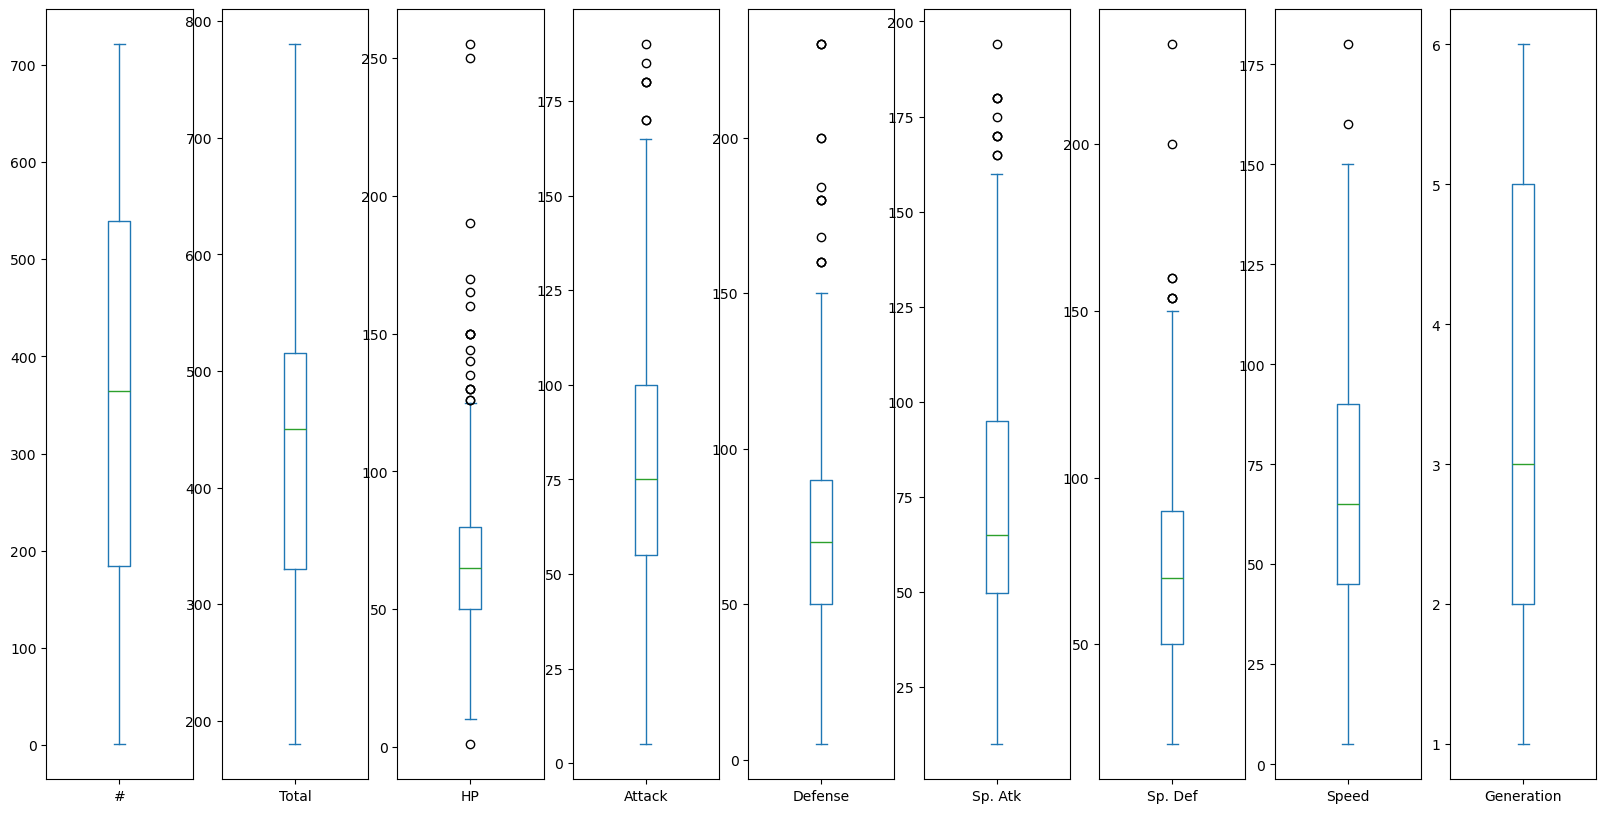

In [74]:
df.plot(kind="box",subplots=True,sharey=False,figsize=(20,10))

In [75]:
%pip install feature-engine
from feature_engine.outliers import Winsorizer

list1=['HP','Attack','Defense','Sp. Atk','Sp. Def','Speed']

Note: you may need to restart the kernel to use updated packages.


In [76]:
a = Winsorizer (capping_method='iqr',tail='both',fold=1.5,variables=list1)

df[list1]=a.fit_transform(df[list1])

In [77]:
from sklearn.preprocessing import LabelEncoder

type1_encoder = LabelEncoder()
type2_encoder = LabelEncoder()
legendary_encoder = LabelEncoder()

df['Type 1'] = type1_encoder.fit_transform(df['Type 1'])
df['Type 2'] = type2_encoder.fit_transform(df['Type 2'])
df['Legendary'] = legendary_encoder.fit_transform(df['Legendary'])

In [78]:
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,9,13,318,45,49.0,49,65.0,65,45.0,1,0
1,2,Ivysaur,9,13,405,60,62.0,63,80.0,80,60.0,1,0
2,3,Venusaur,9,13,525,80,82.0,83,100.0,100,80.0,1,0
3,3,VenusaurMega Venusaur,9,13,625,80,100.0,123,122.0,120,80.0,1,0
4,4,Charmander,6,7,309,39,52.0,43,60.0,50,65.0,1,0


In [79]:
# Columns '#' and 'Name' were already removed during preprocessing
# No action needed

In [80]:
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,9,13,318,45,49.0,49,65.0,65,45.0,1,0
1,2,Ivysaur,9,13,405,60,62.0,63,80.0,80,60.0,1,0
2,3,Venusaur,9,13,525,80,82.0,83,100.0,100,80.0,1,0
3,3,VenusaurMega Venusaur,9,13,625,80,100.0,123,122.0,120,80.0,1,0
4,4,Charmander,6,7,309,39,52.0,43,60.0,50,65.0,1,0


In [87]:
df.drop(['#','Name'], axis=1, inplace=True)

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Type 1      800 non-null    int64  
 1   Type 2      800 non-null    int64  
 2   Total       800 non-null    int64  
 3   HP          800 non-null    int64  
 4   Attack      800 non-null    float64
 5   Defense     800 non-null    int64  
 6   Sp. Atk     800 non-null    float64
 7   Sp. Def     800 non-null    int64  
 8   Speed       800 non-null    float64
 9   Generation  800 non-null    int64  
 10  Legendary   800 non-null    int64  
dtypes: float64(3), int64(8)
memory usage: 68.9 KB


In [89]:
x =df.drop(['Legendary'],axis=1)
y=df['Legendary']

In [90]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2 , random_state=42)

In [91]:
x_train.shape

(640, 10)

In [92]:
x_test.shape

(160, 10)

In [93]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [94]:
y_train.value_counts()

Legendary
0    585
1     55
Name: count, dtype: int64

In [95]:
df['Legendary'].value_counts()

Legendary
0    735
1     65
Name: count, dtype: int64

In [96]:
from imblearn.over_sampling import SMOTE 
oversample= SMOTE()
x_train_smo,y_train_smo=oversample.fit_resample(x_train,y_train)

In [97]:
y_train_smo.value_counts()

Legendary
1    585
0    585
Name: count, dtype: int64

In [98]:
from sklearn.linear_model import LogisticRegression 
model=LogisticRegression()
model.fit(x_train_smo,y_train_smo)

LogisticRegression()

In [99]:
y_pred=model.predict(x_test)

In [100]:
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0])

In [101]:
from sklearn.metrics import confusion_matrix,accuracy_score
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.925
[[138  12]
 [  0  10]]


In [102]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

score=accuracy_score(y_test,y_pred)
print(score)
cm=confusion_matrix(y_test,y_pred)
print(cm)
cr=classification_report(y_test,y_pred)
print(cr)


0.925
[[138  12]
 [  0  10]]
              precision    recall  f1-score   support

           0       1.00      0.92      0.96       150
           1       0.45      1.00      0.62        10

    accuracy                           0.93       160
   macro avg       0.73      0.96      0.79       160
weighted avg       0.97      0.93      0.94       160



In [103]:
from sklearn.metrics import roc_curve
y_prob = model.predict_proba(x_test)[:, 1]

threshold = 0.8
y_pred1 = (y_prob >= threshold).astype(int)

In [104]:
y_pred1

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0])

In [105]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

score=accuracy_score(y_test,y_pred1)
print(score)
cm=confusion_matrix(y_test,y_pred1)
print(cm)
cr=classification_report(y_test,y_pred1)
print(cr)


0.95
[[142   8]
 [  0  10]]
              precision    recall  f1-score   support

           0       1.00      0.95      0.97       150
           1       0.56      1.00      0.71        10

    accuracy                           0.95       160
   macro avg       0.78      0.97      0.84       160
weighted avg       0.97      0.95      0.96       160



In [106]:
import matplotlib.pyplot as plot
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

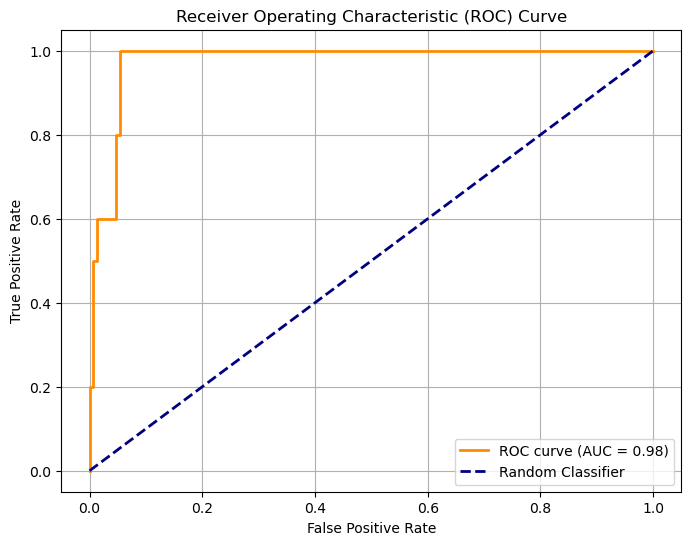

In [107]:
plot.figure(figsize=(8, 6))
plot.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plot.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plot.xlabel('False Positive Rate')
plot.ylabel('True Positive Rate')
plot.title('Receiver Operating Characteristic (ROC) Curve')
plot.legend(loc='lower right')
plot.grid(True)

In [108]:
x

,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
0,9,13,318,45,49.0,49,65.000,65,45.0,1
1,9,13,405,60,62.0,63,80.000,80,60.0,1
2,9,13,525,80,82.0,83,100.000,100,80.0,1
3,9,13,625,80,100.0,123,122.000,120,80.0,1
4,6,7,309,39,52.0,43,60.000,50,65.0,1
...,...,...,...,...,...,...,...,...,...,...
795,15,4,600,50,100.0,150,100.000,150,50.0,6
796,15,4,700,50,160.0,110,160.000,110,110.0,6
797,14,8,600,80,110.0,60,150.000,130,70.0,6
798,14,1,680,80,160.0,60,162.875,130,80.0,6


In [109]:
y

0      0
1      0
2      0
3      0
4      0
      ..
795    1
796    1
797    1
798    1
799    1
Name: Legendary, Length: 800, dtype: int64

In [110]:
new_data = np.array([[15,4,700,50,160.0,110,160,110,110.0,6]])
scaled_new_data = scaler.transform(new_data)
prediction = model.predict(scaled_new_data)
print("Prediction (0=Not Legendary, 1=Legendary):", prediction[0])

Prediction (0=Not Legendary, 1=Legendary): 1


c:\Users\prath\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [111]:
import pickle

final_data = {
    "model": model,
    "scaler": scaler,
    "type1_encoder": type1_encoder,
    "type2_encoder": type2_encoder,
    "threshold": 0.8
}

with open("pokemon_model.pkl", "wb") as f:
    pickle.dump(final_data, f)